In [30]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import mplfinance as mpf

### Import Dataset

In [31]:
df = pd.read_csv('dataset/Sp500_Stock.csv')
df.head()

,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


### Check NA value

In [32]:
df.isna().sum()

date       0
open      11
high       8
low        8
close      0
volume     0
Name       0
dtype: int64

In [33]:
missing_percentage = ((df.isna().sum())/len(df)) * 100
print(f'Missing Percentage :\n{missing_percentage}')

Missing Percentage :
date      0.000000
open      0.001777
high      0.001292
low       0.001292
close     0.000000
volume    0.000000
Name      0.000000
dtype: float64


In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    619040 non-null  str    
 1   open    619029 non-null  float64
 2   high    619032 non-null  float64
 3   low     619032 non-null  float64
 4   close   619040 non-null  float64
 5   volume  619040 non-null  int64  
 6   Name    619040 non-null  str    
dtypes: float64(4), int64(1), str(2)
memory usage: 40.8 MB


In [35]:
# Fill Na Value after checked the data type.
df = df.fillna(0)

In [36]:
# Check the existing NA data again
df.isna().sum()

date      0
open      0
high      0
low       0
close     0
volume    0
Name      0
dtype: int64

In [56]:
# Just get the records from AAL stock
df_aal = df[df['Name']=='AAL']
df_aal['date'] = pd.to_datetime(df['date'])
the_last_date = df_aal['date'].max()
the_begin_date = the_last_date - pd.DateOffset(months=6)
print(f'The last of date: {the_last_date}')
print(f'The begin of date: {the_begin_date}')

# Retrieve the last 6 months of data
df_aal_last_six_months = df_aal[df_aal['date'] >= the_begin_date]
df_aal_last_six_months.head()

The last of date: 2018-02-07 00:00:00
The begin of date: 2017-08-07 00:00:00


,date,open,high,low,close,volume,Name
1131,2017-08-07,50.82,51.130,50.46,50.58,3016726,AAL
1132,2017-08-08,50.68,50.780,49.89,50.00,4274416,AAL
1133,2017-08-09,49.74,49.920,49.23,49.40,5020809,AAL
1134,2017-08-10,49.03,49.340,48.19,48.55,5441375,AAL
1135,2017-08-11,48.50,48.785,47.44,48.35,5610688,AAL


### Visualize Data

In [41]:
# Import related library
from mplfinance.original_flavor import candlestick2_ochl

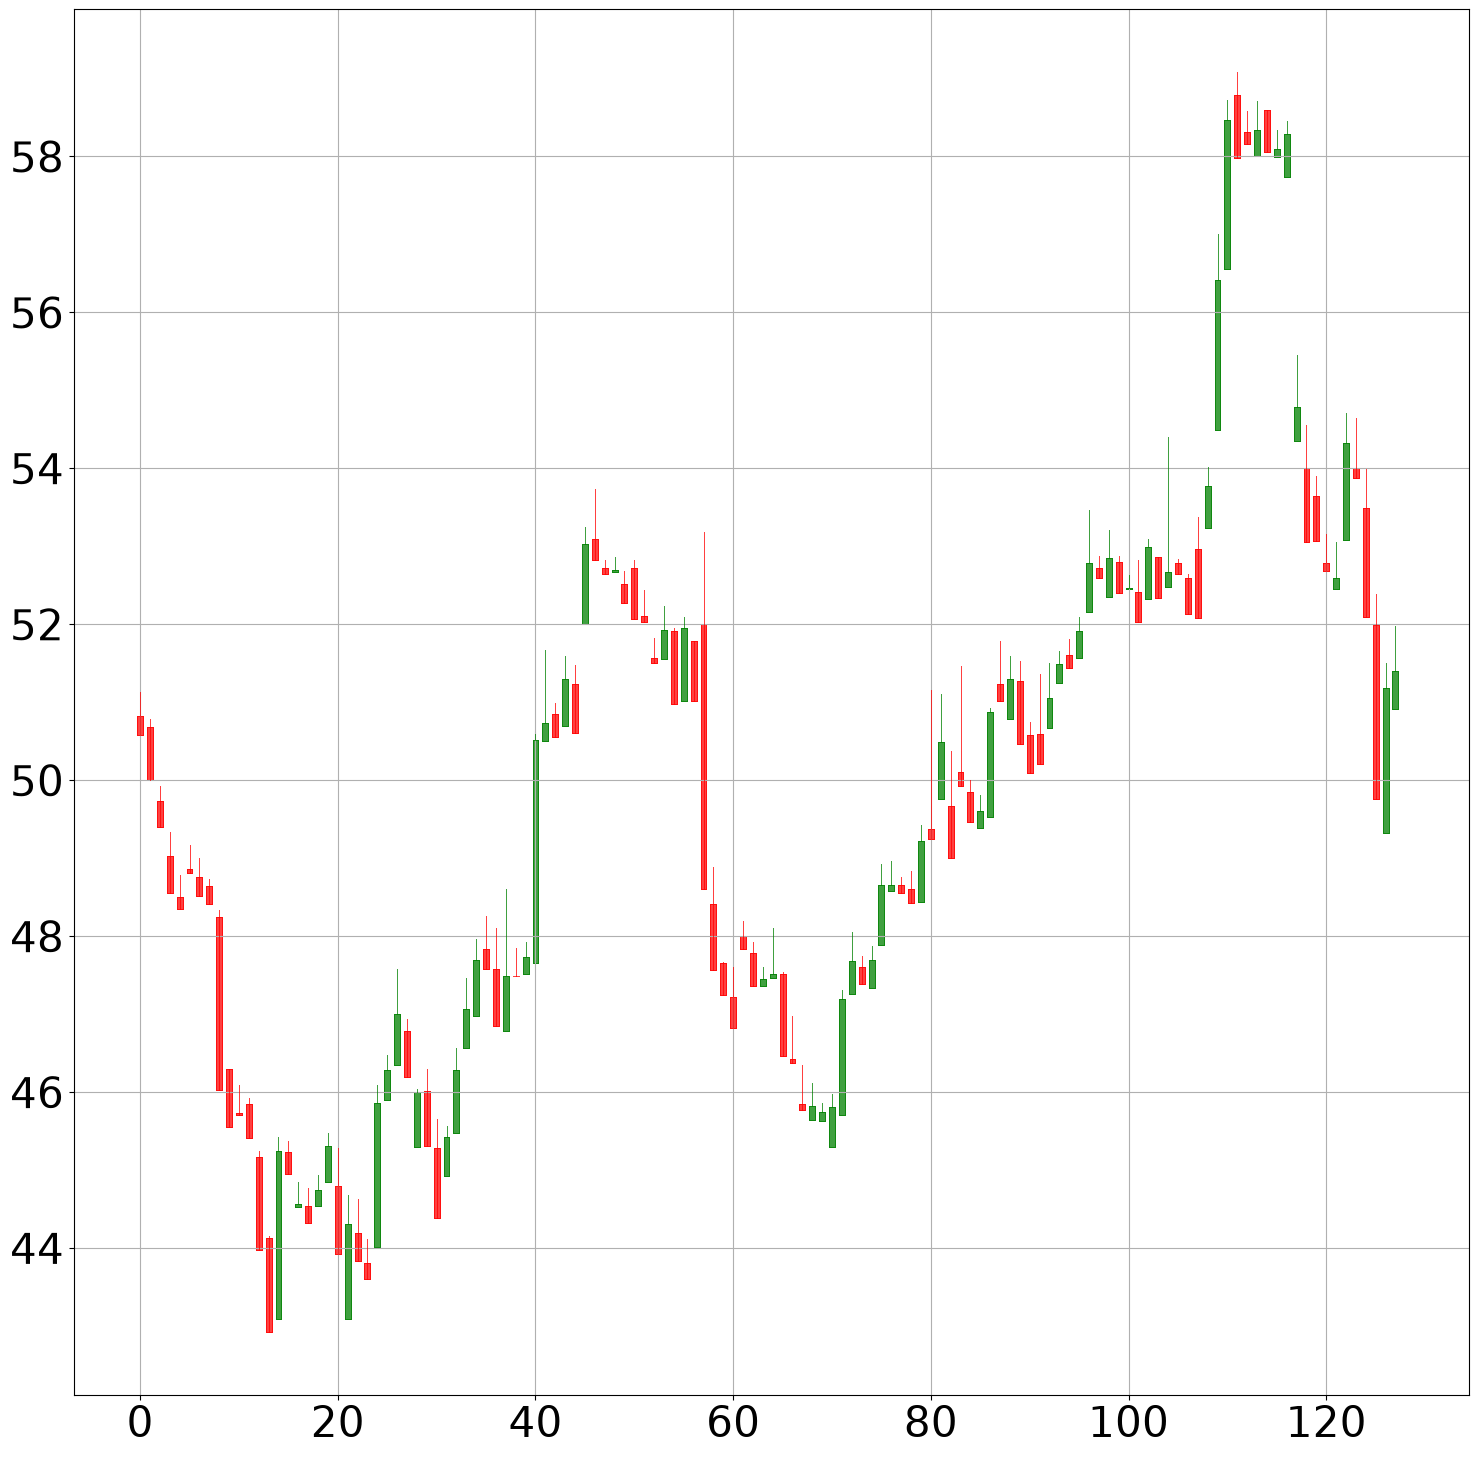

In [57]:
fig = plt.figure(figsize=(18,18))
ax = fig.add_subplot(1, 1, 1)
candlestick2_ochl(
    ax,
    df_aal_last_six_months['open'].values,
    df_aal_last_six_months['close'].values,
    df_aal_last_six_months['high'].values,
    df_aal_last_six_months['close'].values,
    width=0.6,
    colorup='g',
    colordown='r',
    alpha=0.75
)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.grid(True)
plt.show()

### Compute Euclidean Distance

In [130]:
N = df_aal_last_six_months.shape[0]
D = np.zeros((N, N))

# Simplify the name of data frame
cols = ['open', 'close', 'high', 'low']
df_final = df_aal_last_six_months[cols]

In [146]:
# Setup X and y
X = df_final[['open', 'high', 'low']].values
y = df_final[['close']].values

In [132]:
# Compute Euclidean Distance
for i in range(N):
    row_i = X[i]
    for j in range(N):
        row_j = X[j]
        D[i, j] = (row_i[0] - row_j[0]) ** 2 + (row_i[1] - row_j[1]) ** 2 + (row_i[2] - row_j[2]) ** 2

### Apply KNN Regression

In [141]:
k = 8
y_pred = np.zeros(N)

In [142]:
for i in range(N):
    k_indicates = np.argsort(D[i, :])[:k]
    # Compute the average of y
    y_pred[i] = np.sum(y[k_indicates]) / k

In [147]:
def plt_ed(D, k):
    plt.plot(np.arange(N), y_pred, linewidth=2, label="kNN (k="+str(k)+")")

### Visualize Data with KNN Regression

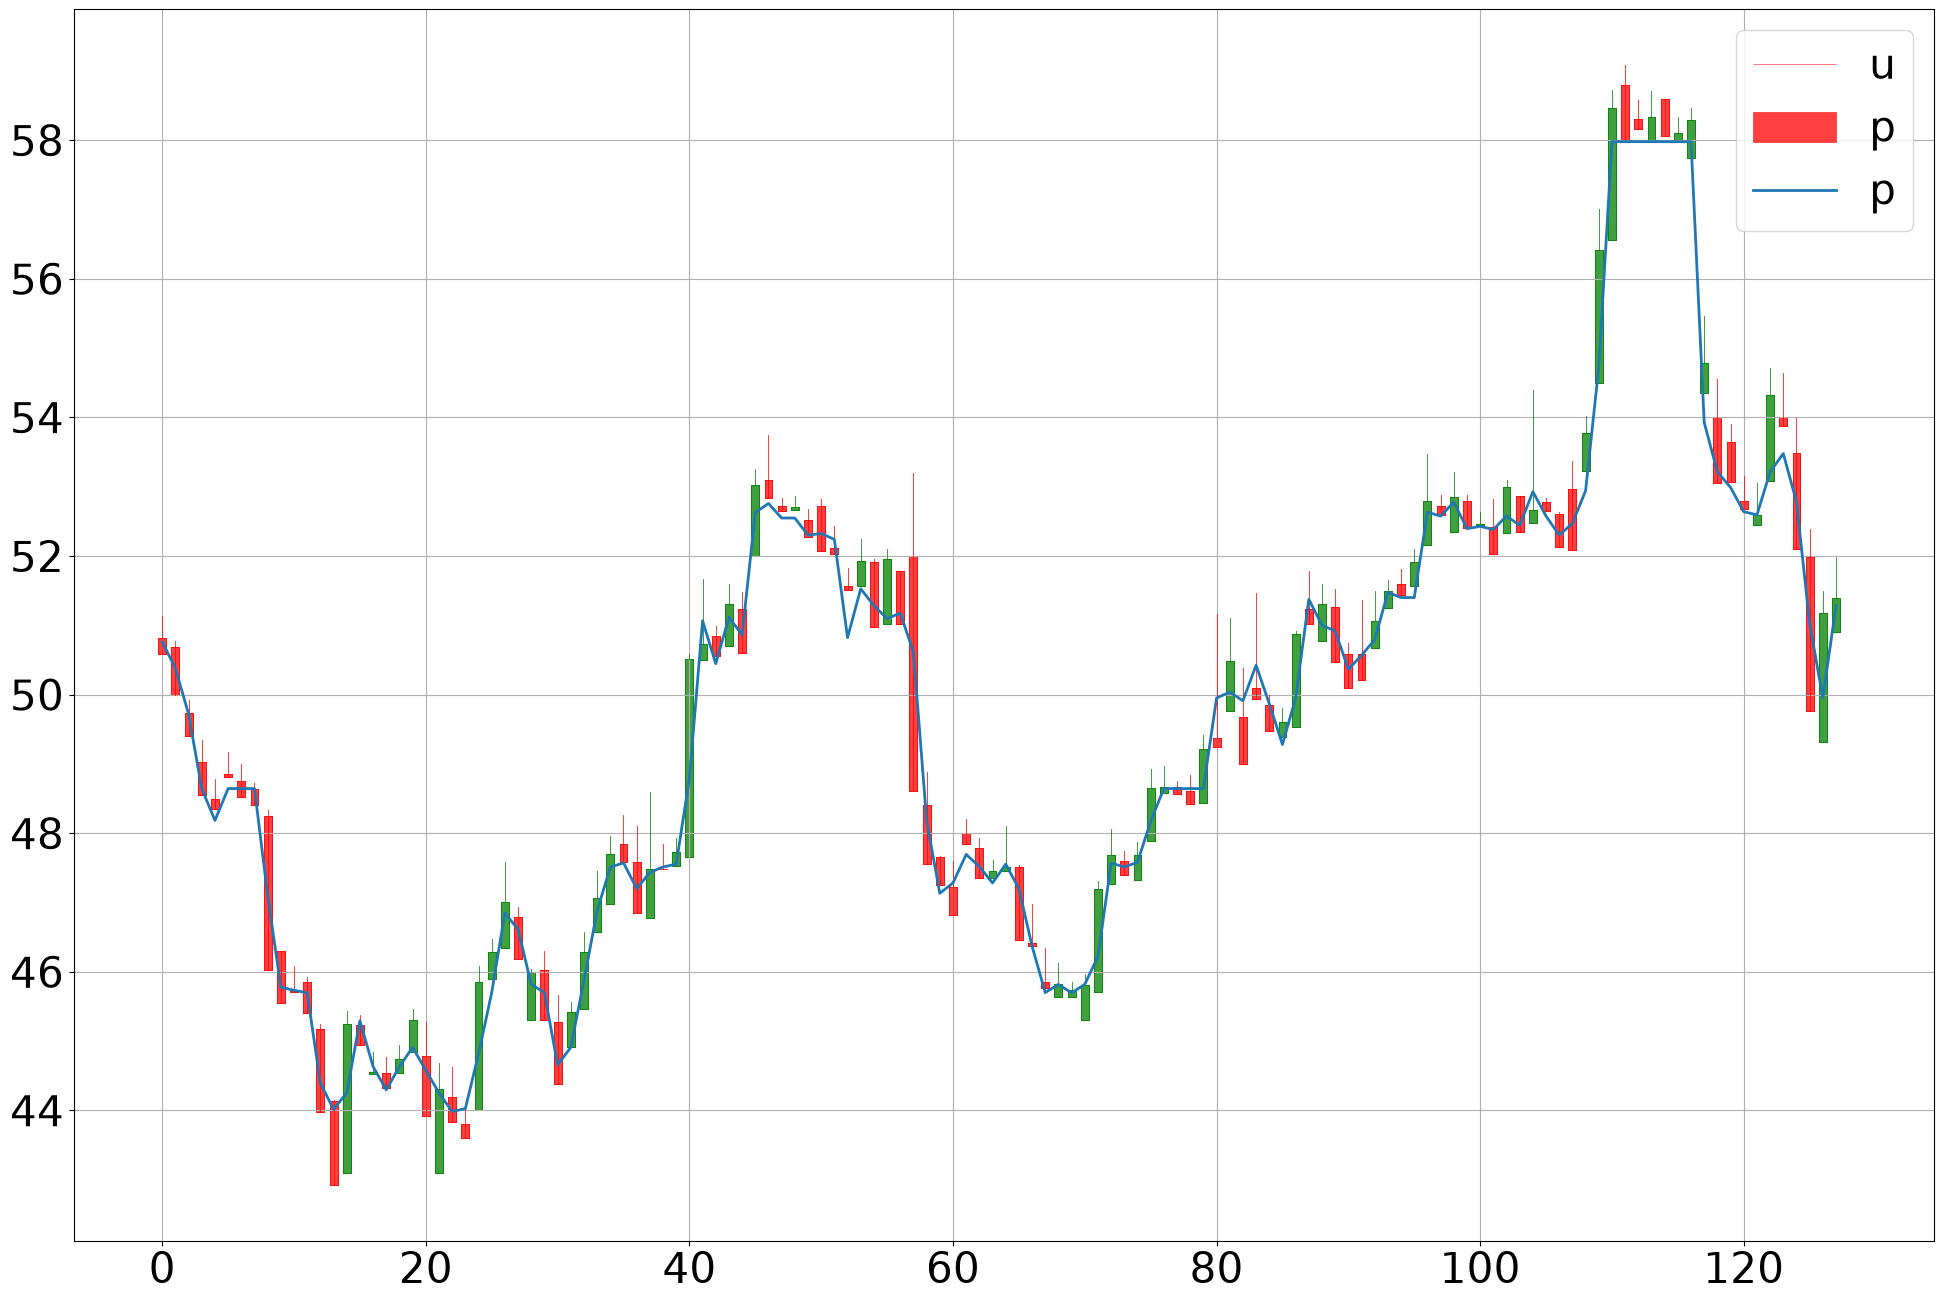

In [148]:
fig = plt.figure(figsize=(24,16))
ax = fig.add_subplot(1, 1, 1)
candlestick2_ochl(
    ax,
    df_aal_last_six_months['open'].values,
    df_aal_last_six_months['close'].values,
    df_aal_last_six_months['high'].values,
    df_aal_last_six_months['close'].values,
    width=0.6,
    colorup='g',
    colordown='r',
    alpha=0.75
)
plt_ed(D, k=8)
plt.grid(True)
plt.legend('upper left', fontsize=30)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.show()